First we are goin to load the data, then split the data.

In [1]:
def extract_L_set(filepath):
    l_set = []
    capture = False
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
        
            # Start capturing when we see the header
            if line.startswith("L set:"):
                capture = True
                continue
        
            # Stop capturing when we reach the B vector
            if line.startswith("B vector:"):
                capture = False
                break
            
            # If we are in the capture zone and the line looks like a list
            if capture and line.startswith("["):
                # ast.literal_eval safely converts the string "[1, 2...]" into a Python list
                row = ast.literal_eval(line)
                l_set.append(row)
    return l_set

In [2]:
import numpy as np
import ast #abstract syntax tree module for safe evaluation of string.
loaded_train_test_data = []
#first we loading the L set from 2003 to 2023
filePath = '../ED_Calculation/2003_2023/results/finalize_L_set_from_2003_to_2023.txt'
loaded_train_test_data = np.array(extract_L_set(filePath))


In [3]:
from sklearn.model_selection import train_test_split
#separate the test_data for Feature and Target
X = loaded_train_test_data[:, :5] #first five col of the row is feature
y = loaded_train_test_data[:, 5] # 6th value is the target

#split for train and val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train {X_train.shape}")
print(f"Shape of y_train{y_train.shape}")
print(f"Shape of X_val{X_val.shape}")
print(f"Shape of y_val{y_val.shape}")

Shape of X_train (116, 5)
Shape of y_train(116,)
Shape of X_val(29, 5)
Shape of y_val(29,)


It is time to define the test data from **2024 to 2025**.

In [4]:
loaded_test_data = []
test_filepath = "../ED_Calculation/2024_current/results/final_result_df_2024_2025.txt"
loaded_test_data = np.array(extract_L_set(test_filepath))
X_test = loaded_test_data[:, :5]
y_test = loaded_test_data[:, 5]


Now we are going to make a Feed Forward Neural Network, which has input layer with 5 feature, a hidden layer with initial neuron size 10 with signmoid function, and a signle neuron output layer with linear function.

In [21]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input


#Create a model
ffnn = Sequential()
# Input layer (5 features)tells the model to expect 5 columns
ffnn.add(Input(shape=(X_train.shape[1],)))
# Hidden layer (10 neurons) 
ffnn.add(Dense(units=10, activation="sigmoid",))
ffnn.add(Dense(units=1, activation="linear"))
ffnn.compile(optimizer="adam", loss='mse', metrics=['mae'])
ffnn.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71 (284.00 B)

 Trainable params: 71 (284.00 B)

 Non-trainable params: 0 (0.00 B)

Now run and train the model

In [22]:

ffnn_history = ffnn.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=1,)
print("Model compiled and trained successfully.")

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.3666 - mae: 0.4810 - val_loss: 0.4845 - val_mae: 0.5611
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3539 - mae: 0.4702 - val_loss: 0.4611 - val_mae: 0.5507
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3457 - mae: 0.4621 - val_loss: 0.4402 - val_mae: 0.5422
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3375 - mae: 0.4552 - val_loss: 0.4237 - val_mae: 0.5350
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3316 - mae: 0.4509 - val_loss: 0.4094 - val_mae: 0.5283
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3275 - mae: 0.4476 - val_loss: 0.3970 - val_mae: 0.5230
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3246 - mae: 0.4451 - val_loss: 0.3866 - val_mae: 0.5190
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3222 - mae: 0.4429 - val_loss: 0.3782 - val_mae: 0.5165
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3210 - mae: 0.4427 - 

In [16]:
test_results = ffnn.evaluate(X_test, y_test, verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0604 - mae: 0.2080


In [17]:
print(f"Test MAE: {test_results[1]:.4}")


Test MAE: 0.208


In [18]:
import pandas as pd
predictions = ffnn.predict(X_test)

# Create a comparison table
results_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': predictions.flatten(),
    'Difference': y_test - predictions.flatten()
})

print("Predictions for the 2024-2025 Test Set:")
display(results_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predictions for the 2024-2025 Test Set:


,Actual Value,Predicted Value,Difference
0,-0.017473,0.051277,-0.068750
1,-0.339443,0.071760,-0.411203
2,0.031541,0.073521,-0.041980
3,-0.215161,0.058879,-0.274040
4,-0.087107,0.039614,-0.126721
5,0.485383,0.060972,0.424410
6,-0.220254,0.077721,-0.297976
7,0.307394,0.094169,0.213225
8,0.306878,0.055394,0.251484
9,0.113420,0.067642,0.045778


### Visualize Model Performance
Plotting the training and validation loss (MSE) and Mean Absolute Error (MAE) over epochs.

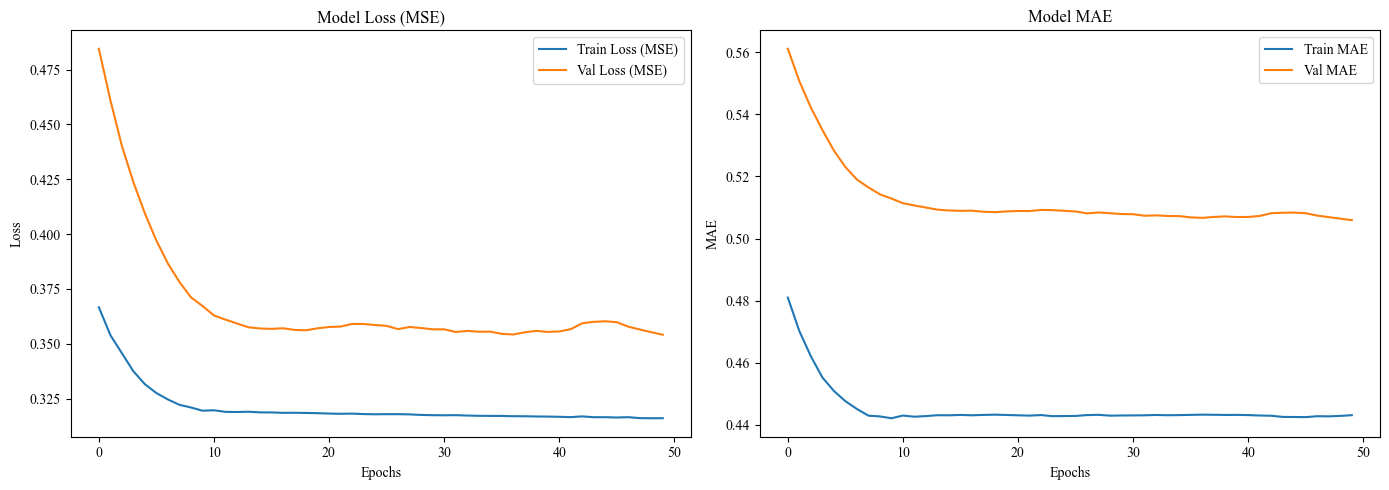

In [23]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss (MSE)
ax1.plot(ffnn_history.history["loss"], label="Train Loss (MSE)")
ax1.plot(ffnn_history.history["val_loss"], label="Val Loss (MSE)")
ax1.set_title("Model Loss (MSE)")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend()

# Plot MAE
ax2.plot(ffnn_history.history["mae"], label="Train MAE")
ax2.plot(ffnn_history.history["val_mae"], label="Val MAE")
ax2.set_title("Model MAE")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("MAE")
ax2.legend()

plt.tight_layout()
plt.show()


### Visualize Predictions vs Actual
Plotting the model's predictions on the test dataset compared to the actual expected values.

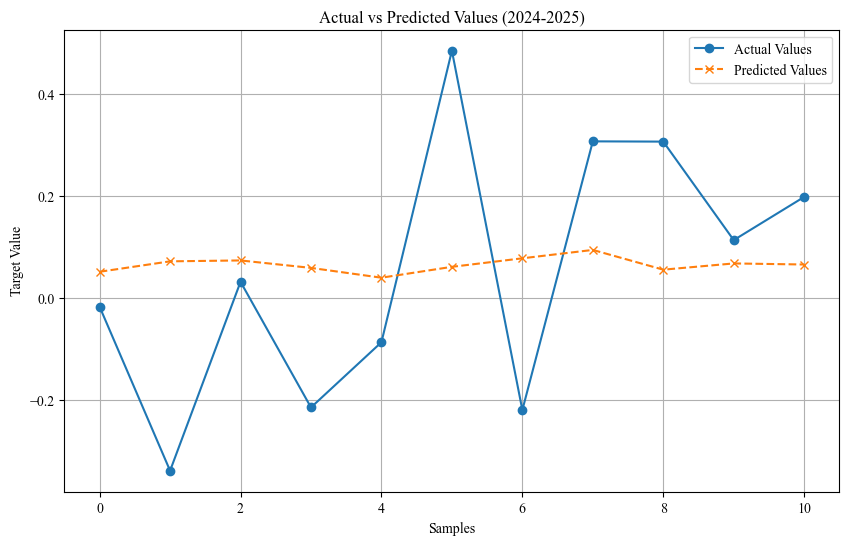

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label="Actual Values", marker="o")
plt.plot(range(len(predictions)), predictions.flatten(), label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025)")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()
